**Task 3. Extrapolation**
Forecast the 200 missing data points at the end of each series. Indicate the uncertainty of your estimate for each point!
• Evaluate how well your proposed solutions are expected to work. 1
• Make sure to avoid overfitting and data leakage in your models.
• Can you use insights from Task 1 to improve extrapolation?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

from pmdarima import auto_arima

In [5]:
# Ignore convergence warnings during .ARIMA fitting process
warnings.filterwarnings('ignore')

# 1. Read data 
data = pd.read_csv("../spiff_data-2.csv", index_col=0)
data = data.reset_index() # 防止 index_col 导致混乱，先重置
if 'day' in data.columns:
    data = data.set_index('day')

# 2. Data cleaning based on Task 1
print("Cleaning anomalous data points (value = 1000.0)...")
data = data.replace(1000.0, np.nan)
# Use limit_area='inside' to only interpolate internal missing values.
# This prevents accidentally filling the 200 missing tail points we need to forecast.
data = data.interpolate(method='linear', limit_area='inside')
print("Data cleaning completed.")





Cleaning anomalous data points (value = 1000.0)...
Data cleaning completed.


In [15]:
def evaluate_model(series, order=(1, 1, 1), test_size=200):
    """
    Evaluate the model's expected performance:
    By retaining the last test_size points as the validation set and using the preceding data as the training set, data leakage is strictly prevented.
    """
    train = series.iloc[:-test_size]
    test = series.iloc[-test_size:]
    
    # Fitting the model
    model = ARIMA(train, order=order)
    fitted_model = model.fit()
    
    # Predict and compare with real test set data
    predictions = fitted_model.forecast(steps=test_size)
    
    # Calculate error index
    mae = mean_absolute_error(test, predictions)
    rmse = np.sqrt(mean_squared_error(test, predictions))
    
    return mae, rmse

def forecast_and_plot(series, col_name, forecast_steps=200):
    """
    The final extrapolation prediction is performed using the fully cleaned data, and the uncertainty is marked.
    """

    # 转换为对数价格，以稳定方差
    log_series = np.log(series.dropna())

    # 自动搜索最优 ARIMA 参数 (针对对数价格)
    print(f"Searching best ARIMA order for {col_name}...")
    try:
        # trace=False 防止输出太多，可以打开看过程
        stepwise_model = auto_arima(log_series, start_p=0, start_q=0,
                                    max_p=3, max_q=3, d=1, 
                                    seasonal=False, trace=False,
                                    error_action='ignore',  
                                    suppress_warnings=True)
        best_order = stepwise_model.order
        print(f"Best order found: {best_order}")
    except:
        best_order = (1, 1, 1) # 回退方案

    # Fit the full dataset
    model = ARIMA(log_series, order=best_order)
    fitted_model = model.fit()
    
    # Perform extrapolation forecasting (obtain the forecast mean and confidence interval).
    forecast_res = fitted_model.get_forecast(steps=forecast_steps)
    pred_mean_log = forecast_res.predicted_mean
    pred_ci_log = forecast_res.conf_int(alpha=0.05) # 95% Confidence interval
    
    #将对数预测值还原为真实价格 (np.exp)
    pred_mean = np.exp(pred_mean_log)
    pred_ci_lower = np.exp(pred_ci_log.iloc[:, 0])
    pred_ci_upper = np.exp(pred_ci_log.iloc[:, 1])

    # Building a future time index
    last_day = series.index[-1]
    future_index = np.arange(last_day + 1, last_day + 1 + forecast_steps)
    pred_mean.index = future_index
    #pred_ci.index = future_index
    pred_ci_lower.index = future_index
    pred_ci_upper.index = future_index
    
    plt.figure(figsize=(12, 5))
    # the last 800 day
    plt.plot(series.index[-800:], series.iloc[-800:], label='Historical Data') 
    plt.plot(pred_mean.index, pred_mean, color='red', label='Forecast Mean')
    
    # Uncertainty interval
    plt.fill_between(pred_ci_lower.index,
                     pred_ci_lower,
                     pred_ci_upper, color='pink', alpha=0.4, label='95% Confidence Interval')
    
    plt.title(f'Extrapolation Forecast & Uncertainty for {col_name}')
    plt.xlabel('Day')
    plt.ylabel('Value')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return pred_mean, pred_ci_lower, pred_ci_upper



Processing Time Series: index
Model Evaluation on last 200 known days:
 -> MAE (Mean Absolute Error): 100.5000
 -> RMSE (Root Mean Squared Error): 115.9030
Forecasting future 200 points with uncertainty...
Searching best ARIMA order for index...


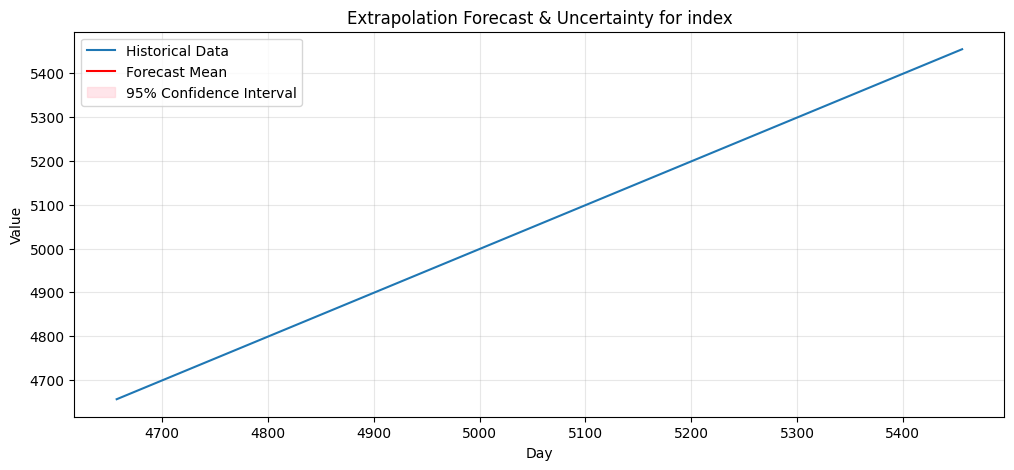


Processing Time Series: gurkor
Model Evaluation on last 200 known days:
 -> MAE (Mean Absolute Error): 0.1645
 -> RMSE (Root Mean Squared Error): 0.1890
Forecasting future 200 points with uncertainty...
Searching best ARIMA order for gurkor...
Best order found: (0, 1, 0)


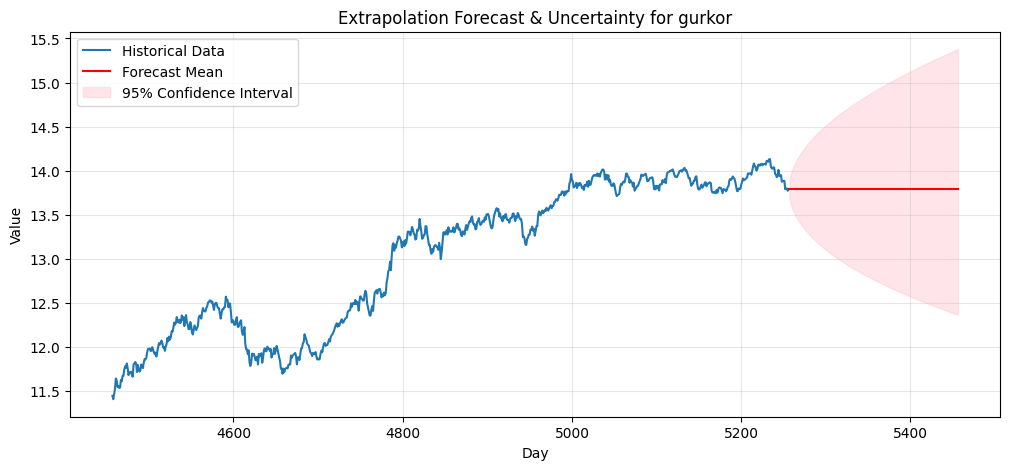


Processing Time Series: guitars
Model Evaluation on last 200 known days:
 -> MAE (Mean Absolute Error): 0.5414
 -> RMSE (Root Mean Squared Error): 0.6372
Forecasting future 200 points with uncertainty...
Searching best ARIMA order for guitars...
Best order found: (0, 1, 0)


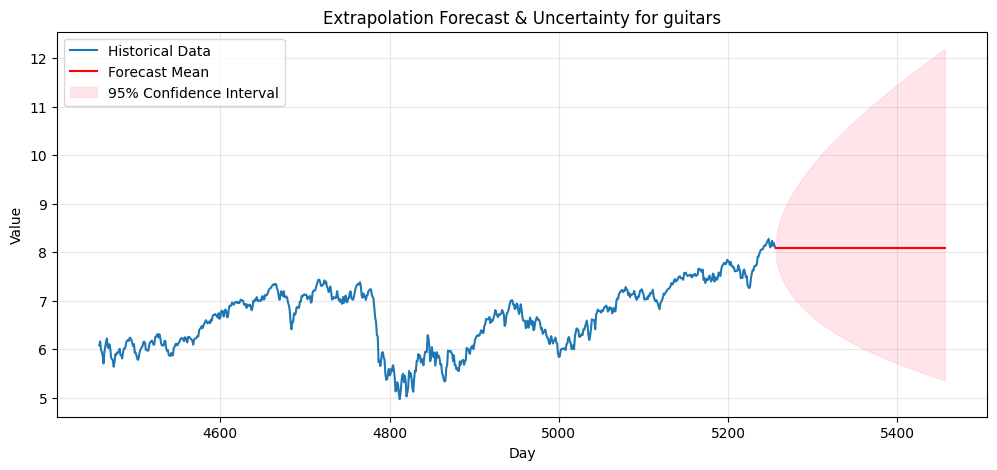


Processing Time Series: slingshots
Model Evaluation on last 200 known days:
 -> MAE (Mean Absolute Error): 0.4892
 -> RMSE (Root Mean Squared Error): 0.6195
Forecasting future 200 points with uncertainty...
Searching best ARIMA order for slingshots...
Best order found: (2, 1, 2)


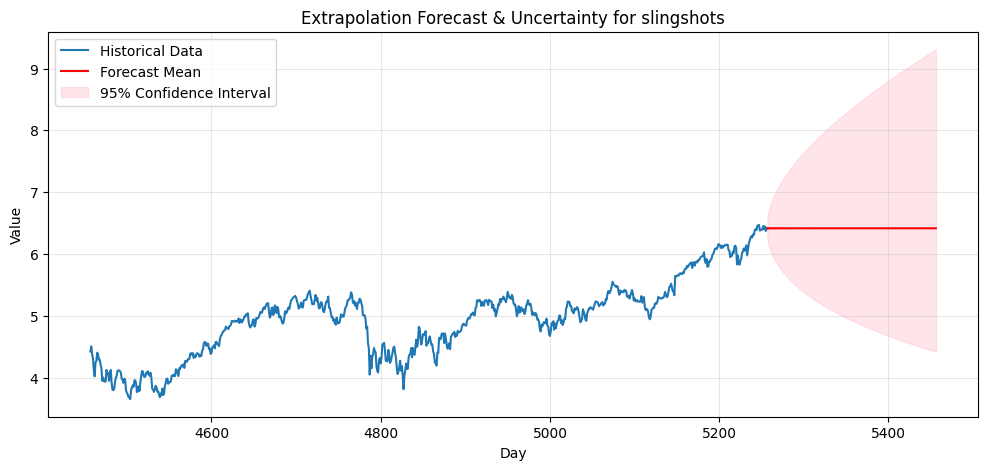


Processing Time Series: stocks
Model Evaluation on last 200 known days:
 -> MAE (Mean Absolute Error): 0.7475
 -> RMSE (Root Mean Squared Error): 0.8948
Forecasting future 200 points with uncertainty...
Searching best ARIMA order for stocks...
Best order found: (0, 1, 0)


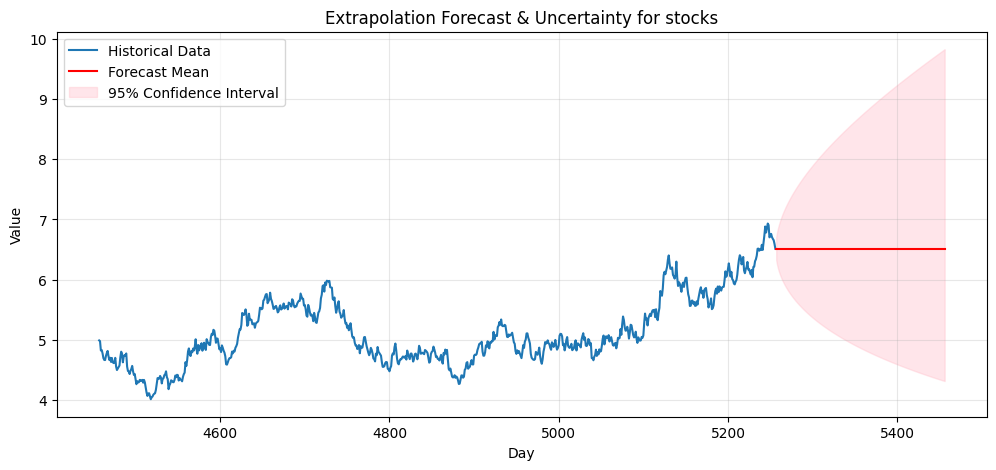


Processing Time Series: sugar
Model Evaluation on last 200 known days:
 -> MAE (Mean Absolute Error): 0.4153
 -> RMSE (Root Mean Squared Error): 0.5705
Forecasting future 200 points with uncertainty...
Searching best ARIMA order for sugar...
Best order found: (2, 1, 0)


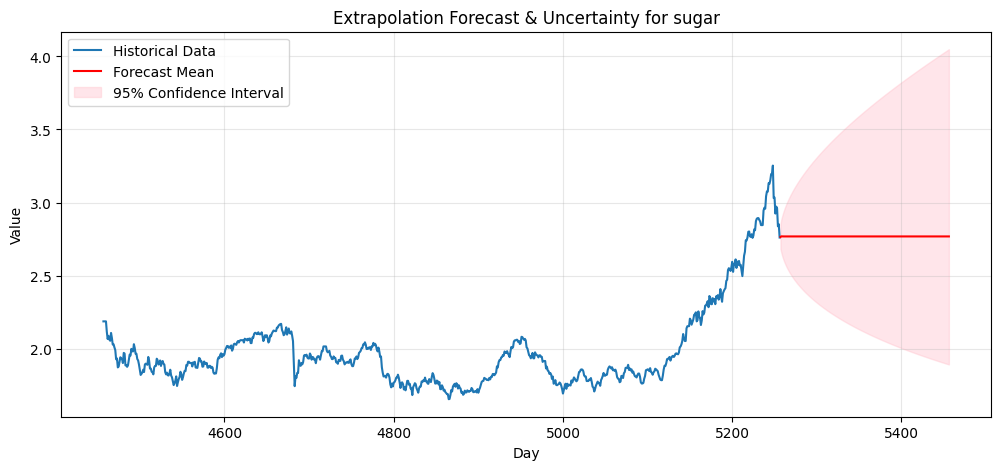


Processing Time Series: water
Model Evaluation on last 200 known days:
 -> MAE (Mean Absolute Error): 0.1790
 -> RMSE (Root Mean Squared Error): 0.2144
Forecasting future 200 points with uncertainty...
Searching best ARIMA order for water...
Best order found: (0, 1, 0)


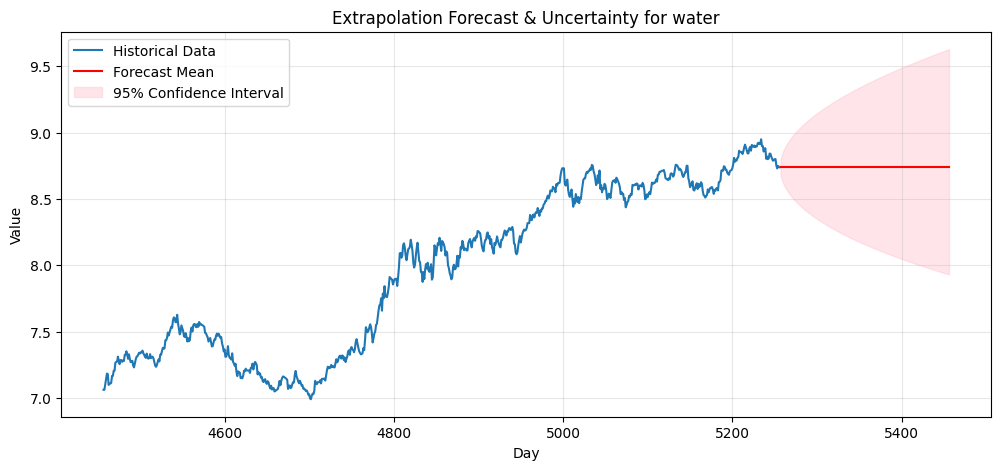


Processing Time Series: tranquillity
Model Evaluation on last 200 known days:
 -> MAE (Mean Absolute Error): 0.8315
 -> RMSE (Root Mean Squared Error): 1.0150
Forecasting future 200 points with uncertainty...
Searching best ARIMA order for tranquillity...
Best order found: (0, 1, 0)


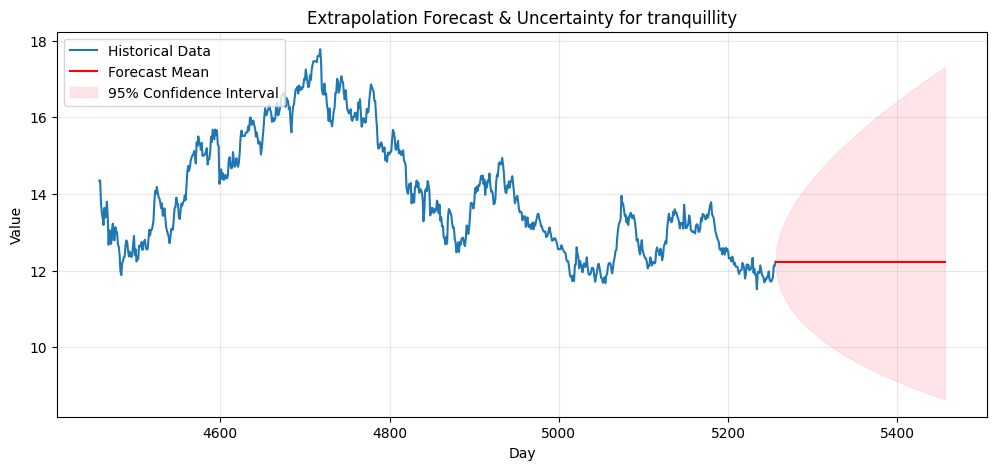


Overall Evaluation Metrics:
Empty DataFrame
Columns: []
Index: []


In [17]:
# Store the final prediction data.
final_forecasts = {}
evaluation_results = {}

# Assuming you want to forecast all valid time series columns
cols_to_forecast = [col for col in data.columns if col != 'day']


for col in cols_to_forecast:
    print(f"\n{'='*40}")
    print(f"Processing Time Series: {col}")
    print(f"{'='*40}")

    # Isolate known data by dropping the missing 200 tail points
    known_series = data[col].dropna()
    
    # Define ARIMA parameters (p, d, q)
    # For financial data with a clear trend, d=1 is a common stabilization technique to prevent overfitting.
    # 对于有明显趋势的金融数据，d=1 (一阶差分) 是防止过拟合的常用稳定化手段
    best_order = (1, 1, 1) 
    
    # 1. Assess expected performance (outputs MAE and RMSE)
    mae, rmse = evaluate_model(known_series, order=best_order, test_size=200)
    print(f"Model Evaluation on last 200 known days:")
    print(f" -> MAE (Mean Absolute Error): {mae:.4f}")
    print(f" -> RMSE (Root Mean Squared Error): {rmse:.4f}")
    
    # 2. Predict the next 200 steps and plot the uncertainty band.
    print(f"Forecasting future 200 points with uncertainty...")
    pred_mean, pred_ci_lower, pred_ci_upper = forecast_and_plot(known_series, col, forecast_steps=200)
    
    # Store the results
    final_forecasts[col] = {
        'forecast_mean': pred_mean,
        'confidence_interval': pred_ci_lower, 
        'confidence_interval': pred_ci_upper
    }

# Display overall evaluation metrics
eval_df = pd.DataFrame.from_dict(evaluation_results, orient='index')
print("\nOverall Evaluation Metrics:")
print(eval_df)